In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
plant_data = pd.read_csv('../data/final_dataset.csv')
plant_data

,ORISPL,YEAR,PSTATABB,NAMEPCAP,CAPFAC,SECTOR,PLFUELCT,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,POST
0,7818,2020,IL,173.0,0.0196,Electric Utility,GAS,29764.0,248594.0,14645.0,984.042,0,0
1,10865,2020,IL,335.0,0.4016,Industrial CHP,COAL,1178599.0,4822371.0,486846.0,826.144,0,0
2,10866,2020,IL,64.0,0.1276,Industrial CHP,GAS,71548.0,394715.0,23069.0,644.851,0,0
3,55279,2020,IL,1086.2,0.0808,IPP Non-CHP,GAS,768846.0,7770819.0,461804.0,1201.292,0,0
4,889,2020,IL,1894.1,0.2447,IPP Non-CHP,COAL,4060737.0,42583478.0,4466152.0,2199.675,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,3948,2021,WV,1632.6,0.3335,Electric Utility,COAL,4769104.0,49696486.0,5098240.0,2138.029,0,1
1796,3954,2021,WV,1680.9,0.3741,Electric Utility,COAL,5508707.0,57367773.0,5885931.0,2136.956,0,1
1797,6264,2021,WV,1300.0,0.6263,Electric Utility,COAL,7132758.0,71684682.0,7353642.0,2061.935,0,1
1798,55349,2021,WV,344.0,0.4156,IPP Non-CHP,GAS,1252463.0,13022037.0,774961.0,1237.499,0,1


In [6]:
treat_0 = plant_data.loc[plant_data["TREATED"] == 0].describe()
treat_1 = plant_data.loc[plant_data["TREATED"] == 1].describe()

treat_0

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,POST
count,1594.000000,1594.000000,1594.000000,1594.000000,1.594000e+03,1.594000e+03,1.594000e+03,1594.000000,1594.0,1594.000000
mean,25684.429737,2020.406524,725.500565,0.262922,2.072733e+06,1.943825e+07,1.717742e+06,2330.626174,0.0,0.473651
std,25708.406896,1.711923,735.610746,0.253080,2.999809e+06,2.887644e+07,2.870106e+06,14829.103375,0.0,0.499462
min,54.000000,2018.000000,25.000000,0.000000,-5.759600e+04,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000
25%,2727.000000,2019.000000,120.000000,0.028025,5.848025e+04,6.185315e+05,3.534650e+04,913.285000,0.0,0.000000
50%,7826.000000,2020.000000,521.900000,0.180200,4.903100e+05,4.671072e+06,3.081245e+05,1426.299500,0.0,0.000000
75%,55237.000000,2022.000000,1097.500000,0.463650,3.518294e+06,2.986895e+07,2.092044e+06,2156.074000,0.0,1.000000
max,64854.000000,2023.000000,3718.200000,0.939800,1.763180e+07,1.739933e+08,1.793342e+07,533536.520000,0.0,1.000000


In [7]:
treat_1

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,POST
count,206.000000,206.000000,206.000000,206.000000,2.060000e+02,2.060000e+02,2.060000e+02,206.000000,206.0,206.000000
mean,30435.242718,2020.422330,623.616019,0.237230,1.690922e+06,1.299421e+07,8.208314e+05,1442.829039,1.0,0.480583
std,24777.656537,1.725359,516.088605,0.256090,2.661892e+06,1.876404e+07,1.157272e+06,873.109619,0.0,0.500840
min,3775.000000,2018.000000,27.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.0,0.000000
25%,7032.000000,2019.000000,254.200000,0.021575,5.719725e+04,6.676122e+05,3.211550e+04,848.173250,1.0,0.000000
50%,10633.000000,2020.000000,475.000000,0.110600,4.266650e+05,3.726636e+06,2.078860e+05,1230.509000,1.0,0.000000
75%,55381.000000,2022.000000,848.000000,0.446125,2.385013e+06,1.702965e+07,1.314001e+06,1712.831250,1.0,1.000000
max,59913.000000,2023.000000,2081.900000,0.872100,1.151319e+07,7.504928e+07,4.460053e+06,5821.306000,1.0,1.000000


In [8]:
post_0 = plant_data.loc[plant_data["POST"] == 0].describe()
post_1 = plant_data.loc[plant_data["POST"] == 1].describe()

post_0

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,POST
count,946.000000,946.000000,946.000000,946.000000,9.460000e+02,9.460000e+02,9.460000e+02,946.000000,946.000000,946.0
mean,24836.877378,2018.977801,737.299894,0.242669,1.975069e+06,1.836140e+07,1.615173e+06,1680.865116,0.113108,0.0
std,25370.746783,0.816842,747.668631,0.247619,2.992596e+06,2.842229e+07,2.807540e+06,1408.205201,0.316892,0.0
min,54.000000,2018.000000,25.200000,0.000000,-5.759600e+04,0.000000e+00,0.000000e+00,0.000000,0.000000,0.0
25%,2828.750000,2018.000000,120.000000,0.021600,4.496250e+04,4.940918e+05,2.954400e+04,955.801750,0.000000,0.0
50%,7811.500000,2019.000000,509.100000,0.139700,4.029140e+05,4.322828e+06,2.619955e+05,1436.463000,0.000000,0.0
75%,55224.000000,2020.000000,1099.800000,0.444450,3.143880e+06,2.796604e+07,1.968652e+06,2156.146250,0.000000,0.0
max,63632.000000,2020.000000,3718.200000,0.908600,1.763180e+07,1.739933e+08,1.793342e+07,20660.147000,1.000000,0.0


In [9]:
post_1

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,POST
count,854.000000,854.000000,854.000000,854.000000,8.540000e+02,8.540000e+02,8.540000e+02,854.000000,854.000000,854.0
mean,27769.268150,2021.992974,687.853747,0.279159,2.088819e+06,1.907669e+07,1.615009e+06,2836.232439,0.115925,1.0
std,25865.791983,0.815988,675.430325,0.258627,2.934504e+06,2.748651e+07,2.673061e+06,20202.124482,0.320323,0.0
min,54.000000,2021.000000,25.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.0
25%,2921.500000,2021.000000,126.675000,0.033425,6.827075e+04,7.776612e+05,3.800375e+04,874.467250,0.000000,1.0
50%,8029.000000,2022.000000,519.000000,0.210150,5.276365e+05,5.165656e+06,3.209535e+05,1351.078000,0.000000,1.0
75%,55263.000000,2023.000000,1055.000000,0.491625,3.635700e+06,2.983336e+07,1.995635e+06,2132.800250,0.000000,1.0
max,64854.000000,2023.000000,3339.500000,0.939800,1.534952e+07,1.552782e+08,1.629002e+07,533536.520000,1.000000,1.0


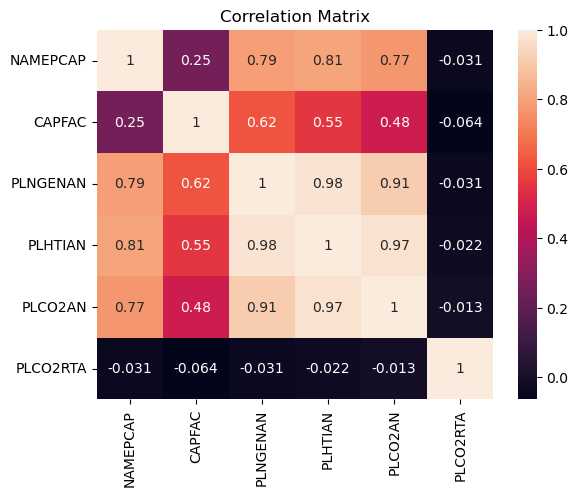

In [10]:
## Correlation Matrix
corr_matrix = plant_data[['NAMEPCAP','CAPFAC','PLNGENAN','PLHTIAN', 'PLCO2AN', 'PLCO2RTA']].corr()
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix')
plt.savefig('../figures/correlation_matrix.png')
plt.show()

In [11]:
plant_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ORISPL    1800 non-null   int64  
 1   YEAR      1800 non-null   int64  
 2   PSTATABB  1800 non-null   object 
 3   NAMEPCAP  1800 non-null   float64
 4   CAPFAC    1800 non-null   float64
 5   SECTOR    1799 non-null   object 
 6   PLFUELCT  1800 non-null   object 
 7   PLNGENAN  1800 non-null   float64
 8   PLHTIAN   1800 non-null   float64
 9   PLCO2AN   1800 non-null   float64
 10  PLCO2RTA  1800 non-null   float64
 11  TREATED   1800 non-null   int64  
 12  POST      1800 non-null   int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 182.9+ KB


In [12]:
plant_data

,ORISPL,YEAR,PSTATABB,NAMEPCAP,CAPFAC,SECTOR,PLFUELCT,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,POST
0,7818,2020,IL,173.0,0.0196,Electric Utility,GAS,29764.0,248594.0,14645.0,984.042,0,0
1,10865,2020,IL,335.0,0.4016,Industrial CHP,COAL,1178599.0,4822371.0,486846.0,826.144,0,0
2,10866,2020,IL,64.0,0.1276,Industrial CHP,GAS,71548.0,394715.0,23069.0,644.851,0,0
3,55279,2020,IL,1086.2,0.0808,IPP Non-CHP,GAS,768846.0,7770819.0,461804.0,1201.292,0,0
4,889,2020,IL,1894.1,0.2447,IPP Non-CHP,COAL,4060737.0,42583478.0,4466152.0,2199.675,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,3948,2021,WV,1632.6,0.3335,Electric Utility,COAL,4769104.0,49696486.0,5098240.0,2138.029,0,1
1796,3954,2021,WV,1680.9,0.3741,Electric Utility,COAL,5508707.0,57367773.0,5885931.0,2136.956,0,1
1797,6264,2021,WV,1300.0,0.6263,Electric Utility,COAL,7132758.0,71684682.0,7353642.0,2061.935,0,1
1798,55349,2021,WV,344.0,0.4156,IPP Non-CHP,GAS,1252463.0,13022037.0,774961.0,1237.499,0,1
